In [61]:
import os
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
from scipy.integrate import quad
import matplotlib.pyplot as plt
from labmate.acquisition_notebook import AcquisitionAnalysisManager

In [62]:
from utils.plot_style import set_plot_style 
set_plot_style()

In [63]:
wavelength = 390e-9  # 390 nm in meters

## QPM Temperature

In [4]:
# path_folder_data = r"./data/data_temp_SHG/temp_scan 04 29" # nice
# path_folder_data = r"./data/data_temp_SHG/temp_scan 05 05"
# path_folder_data = r"./data/data_temp_SHG/temp_scan 05 13"
path_folder_data = r"./data/data_temp_SHG/temperature_scan_cavity_lock"
folder_data_files = os.listdir(path_folder_data)
print(folder_data_files)

['2026-06-09_ppktp_20_1_001', '2026-06-11_ppktp_svenska_10_001', '2026-06-11_ppktp_svenska_10_002', '2026-06-11_ppktp_svenska_10_003', '2026-06-12_ppktp_svenska_10_001', '2026-06-12_ppktp_svenska_10_002', '2026-06-12_ppktp_svenska_20_jesse_001', '2026-06-15_ppktp_svenska_20_jesse_001', '2026-06-15_ppktp_svenska_20_jesse_002', '2026-06-15_ppktp_svenska_20_jesse_003', 'temperature_scan_cavity_lock_ppktp_svenska_10']


In [54]:
# fine data scan :
# name_exp = 'temperature_scan'
# name = "2026_04_29__15_59_36__temperature_scan.h5"
# name = "2026_05_05__08_48_24__temperature_scan.h5"
# name = "2026_05_13__11_59_17__temperature_scan.h5" # single pass of cavity (round-trip alignment was not matching 0-order beam)

# name_exp = 'temperature_scan_cavity'
# name = "2026-06-04_ppktp_20_1_001"
# full_path = os.path.join(path_folder_data, name_exp, name)

# full_path = r"./data/data_temp_SHG/temperature_scan_cavity/2026-06-04_ppktp_20_1_001/temperature_scan_cavity_ppktp_20_1/"
# full_path = r"./data/data_temp_SHG/temperature_scan_cavity_lock/2026-06-11_ppktp_svenska_10_002/temperature_scan_cavity_lock_ppktp_svenska_10/"

full_path = r"data/data_temp_SHG/SHG_temp_input_power_scan/2026-06-15_ppktp_svenska_20_luke_001/SHG_temp_input_power_scan_ppktp_svenska_20_luke/"
# aqm = AcquisitionAnalysisManager( os.path.join(path_folder_data, name_exp))
aqm = AcquisitionAnalysisManager(full_path)

### Single QPM

In [55]:
# aqm.analysis_cell(filename=full_path+"2026_06_04__15_36_00__temperature_scan_cavity_ppktp_20_1.h5")
# aqm.analysis_cell(filename=full_path+"2026_06_11__12_03_14__temperature_scan_cavity_lock_ppktp_svenska_10.h5") # 10 mm
aqm.analysis_cell(filename=full_path+"2026_06_15__16_18_19__SHG_temp_input_power_scan_ppktp_svenska_20_luke.h5")

print(aqm.data)

INFO:2026_06_15__16_18_19__SHG_temp_input_power_scan_ppktp_svenska_20_luke


AnalysisData (rw) (not saved): 
 {
    "acquisition_cell" (r): {
        "1": "variable of type str"
    },
    "error_in_mW" (r): "5.197e-02 (type : float64)",
    "experiment_name" (r): "variable of type str",
    "info" (r): {
        "acquisition_duration": "6.449e+02 (type : float64)",
        "logs": "variable of type str",
        "prints": "variable of type str"
    },
    "list_SHG_errors" (r): "shape: (26,) (type: ndarray)",
    "list_SHG_powers" (r): "shape: (26,) (type: ndarray)",
    "list_Terrors" (r): "shape: (26,) (type: ndarray)",
    "list_Tmeas" (r): "shape: (26,) (type: ndarray)",
    "pump_power_mW" (r): "1.037e+02 (type : float64)",
    "useful" (r): "variable of type bool"
}


In [56]:
list_T = np.array(aqm.data['list_Tmeas'])
list_P = np.array(aqm.data['list_SHG_powers'])
list_Perr = np.array(aqm.data['list_SHG_errors'])
list_Terr = np.array(aqm.data['list_Terrors'])

In [57]:
threshold = 0.005  # adjust based on your noise floor

mask = list_P > threshold

list_P = list_P[mask]
list_T = list_T[mask]
list_Perr = list_Perr[mask]
list_Terr = list_Terr[mask]

In [58]:
# Quasi-phase-matching fit function
def qpm_fit(T, I0, T0, dT, B):
    """
    A_fit = I0 * sinc^2( (T - T0) / dT ) + B
    """
    x = (T - T0) / dT
    return I0 * ((np.sinc(x))**2) + B

In [59]:
# protect against zero/invalid uncertainties
sigma = np.asarray(list_Perr, dtype=float)
sigma[~np.isfinite(sigma) | (sigma <= 0)] = np.nanmedian(sigma[sigma > 0])

p0 = [
    np.max(list_P) - np.min(list_P),
    list_T[np.argmax(list_P)],
    (np.max(list_T) - np.min(list_T)) / 10,
    np.min(list_P)
]

bounds = (
    [0, np.min(list_T), 1e-6, -np.inf],   # lower: I0, T0, dT, B
    [np.inf, np.max(list_T), np.inf, np.inf]
)

popt, pcov = curve_fit(
    qpm_fit,
    list_T,
    list_P,
    p0=p0,
    sigma=sigma,
    absolute_sigma=True,
    bounds=bounds,
    maxfev=10000
)

I0, T0, dT, B = popt
perr = np.sqrt(np.diag(pcov))

print(f"Estimated temperature for maximum SHG power: {T0:.3f} ± {perr[1]:.3f} °C")
print(f"I0 = {I0:.4g} ± {perr[0]:.4g}")
print(f"dT = {dT:.4g} ± {perr[2]:.4g}")
print(f"B  = {B:.4g} ± {perr[3]:.4g}")

Tfit = np.linspace(np.min(list_T), np.max(list_T), 1000)
Pfit = qpm_fit(Tfit, *popt)


Estimated temperature for maximum SHG power: 43.382 ± 0.001 °C
I0 = 5.92 ± 0.008419
dT = 0.6076 ± 0.0007956
B  = 0.311 ± 0.001203


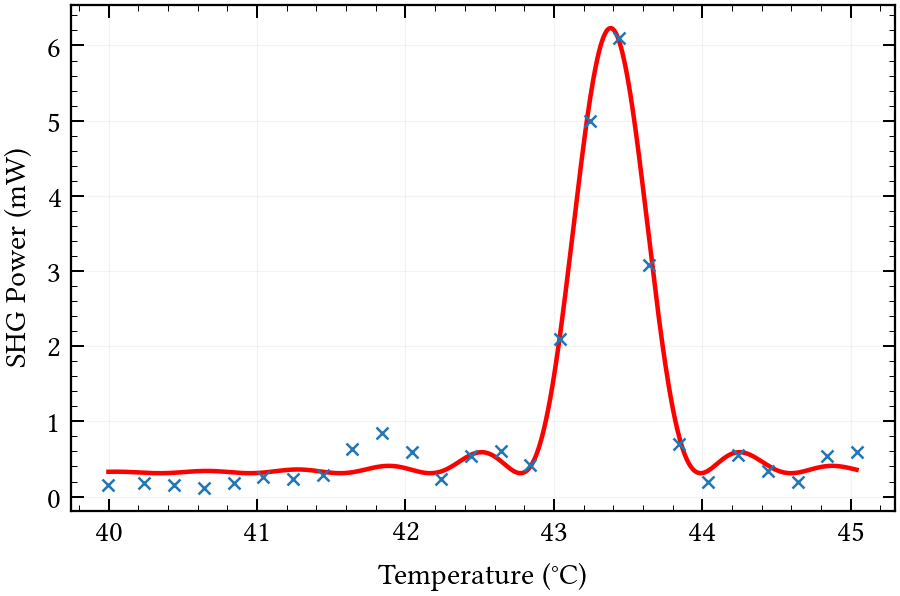

In [60]:
set_plot_style()

plt.errorbar(list_T, list_P , xerr=list_Terr, yerr=list_Perr, fmt='x', label='data')
plt.plot(Tfit, qpm_fit(Tfit, *popt), 'r-', label='fit')
plt.xlabel('Temperature (°C)')
plt.ylabel('SHG Power (mW)')
# plt.title('SHG Power vs Temperature')
plt.grid()
plt.show()


### QPM vs $P_{in}$

In [64]:
# QPM vs Input power scan :
# path_folder_data = r"./data/data_temp_SHG/temperature_scan_cavity_lock"
# name = "2026-06-11_ppktp_svenska_10_003"
# name_exp = "temperature_scan_cavity_lock_ppktp_svenska_10"

path_folder_data = r"./data/data_temp_SHG/SHG_temp_input_power_scan"

# name = "2026-06-15_ppktp_svenska_20_jesse_003"
# name_exp = "SHG_temp_input_power_scan_ppktp_svenska_20_jesse"

name = "2026-06-16_ppktp_svenska_20_luke_001"
name_exp = "SHG_temp_input_power_scan_ppktp_svenska_20_luke"

full_path = os.path.join(path_folder_data, name, name_exp)
print(full_path)

file_list = os.listdir(full_path)
# print file one by one on single lines
print(f"Files in {full_path}:")
for filename in file_list:
    print(filename)

aqm = AcquisitionAnalysisManager(full_path)

./data/data_temp_SHG/SHG_temp_input_power_scan\2026-06-16_ppktp_svenska_20_luke_001\SHG_temp_input_power_scan_ppktp_svenska_20_luke
Files in ./data/data_temp_SHG/SHG_temp_input_power_scan\2026-06-16_ppktp_svenska_20_luke_001\SHG_temp_input_power_scan_ppktp_svenska_20_luke:
2026_06_16__08_24_57__SHG_temp_input_power_scan_ppktp_svenska_20_luke.h5
2026_06_16__08_28_06__SHG_temp_input_power_scan_ppktp_svenska_20_luke.h5
2026_06_16__08_32_01__SHG_temp_input_power_scan_ppktp_svenska_20_luke.h5
2026_06_16__08_36_25__SHG_temp_input_power_scan_ppktp_svenska_20_luke.h5
2026_06_16__08_40_38__SHG_temp_input_power_scan_ppktp_svenska_20_luke.h5
2026_06_16__08_44_16__SHG_temp_input_power_scan_ppktp_svenska_20_luke.h5
2026_06_16__08_48_21__SHG_temp_input_power_scan_ppktp_svenska_20_luke.h5
2026_06_16__08_52_34__SHG_temp_input_power_scan_ppktp_svenska_20_luke.h5
2026_06_16__08_56_49__SHG_temp_input_power_scan_ppktp_svenska_20_luke.h5
2026_06_16__09_00_46__SHG_temp_input_power_scan_ppktp_svenska_20_luke

In [73]:
P_in = []
P_in_error = []

P_out_max = []
P_out_error = []

T_meas = []
T_meas_error = []

for filename in os.listdir(full_path):
    aqm.analysis_cell(filename=os.path.join(full_path, filename))
    try:
        list_Tmeas = aqm.data['list_Tmeas']
        list_Terror = aqm.data['list_Terrors']

        list_SHG_powers = aqm.data['list_SHG_powers']
        list_SHG_errors = aqm.data['list_SHG_errors']

        pump_power_mW = aqm.data['pump_power_mW']
        error_in_mW = aqm.data['error_in_mW']

        idx_max = np.argmax(list_SHG_powers)

        P_in.append(pump_power_mW)
        P_in_error.append(error_in_mW)

        P_out_max.append(list_SHG_powers[idx_max])
        P_out_error.append(list_SHG_errors[idx_max])

        T_meas.append(list_Tmeas[idx_max])
        T_meas_error.append(list_Terror[idx_max])


    except KeyError as e:
        print(f"KeyError for file {filename}: {e}. Skipping this file.")

INFO:2026_06_16__08_24_57__SHG_temp_input_power_scan_ppktp_svenska_20_luke


INFO:2026_06_16__08_28_06__SHG_temp_input_power_scan_ppktp_svenska_20_luke


INFO:2026_06_16__08_32_01__SHG_temp_input_power_scan_ppktp_svenska_20_luke


INFO:2026_06_16__08_36_25__SHG_temp_input_power_scan_ppktp_svenska_20_luke


INFO:2026_06_16__08_40_38__SHG_temp_input_power_scan_ppktp_svenska_20_luke


...

INFO:2026_06_16__08_56_49__SHG_temp_input_power_scan_ppktp_svenska_20_luke


INFO:2026_06_16__09_00_46__SHG_temp_input_power_scan_ppktp_svenska_20_luke


INFO:2026_06_16__09_04_35__SHG_temp_input_power_scan_ppktp_svenska_20_luke


INFO:2026_06_16__09_08_25__SHG_temp_input_power_scan_ppktp_svenska_20_luke


INFO:2026_06_16__09_12_26__SHG_temp_input_power_scan_ppktp_svenska_20_luke


In [74]:
print("Input powers (mW):", P_in)
print("Output powers (mW):", P_out_max)
print("Measured temperatures (C):", T_meas)

Input powers (mW): [np.float64(213.61062083333331), np.float64(205.19577866666668), np.float64(191.18878366666664), np.float64(183.19078470833335), np.float64(160.7663407916667), np.float64(149.33141589583332), np.float64(129.90758170833337), np.float64(111.4750045), np.float64(90.64742084166666), np.float64(69.57815509791666), np.float64(50.991187485416674), np.float64(29.47545677291667), np.float64(10.678509683333333)]
Output powers (mW): [np.float64(54.00478630000001), np.float64(47.5134456051282), np.float64(38.512172984615376), np.float64(42.564044112820504), np.float64(36.22803272820513), np.float64(31.32539858717949), np.float64(23.706333202564103), np.float64(19.01551634615385), np.float64(14.62731833846154), np.float64(9.364517714871791), np.float64(5.534182623846154), np.float64(2.1253575943589746), np.float64(0.3690156632307692)]
Measured temperatures (C): [np.float64(42.858000000000004), np.float64(42.85525), np.float64(42.741749999999996), np.float64(42.84), np.float64(42.

In [75]:
P_in = np.array(P_in)
P_in_error = np.array(P_in_error)

P_out_max = np.array(P_out_max)
P_out_error = np.array(P_out_error)

T_meas = np.array(T_meas)
T_meas_error = np.array(T_meas_error)

print("P_in:", P_in)
print("P_in_error:", P_in_error)

print("P_out_max:", P_out_max)
print("P_out_error:", P_out_error)

print("T_meas:", T_meas)
print("T_meas_error:", T_meas_error)

P_in: [213.61062083 205.19577867 191.18878367 183.19078471 160.76634079
 149.3314159  129.90758171 111.4750045   90.64742084  69.5781551
  50.99118749  29.47545677  10.67850968]
P_in_error: [0.14371019 0.15250831 0.13889029 0.07013527 0.11713522 0.04522399
 0.06150165 0.05305135 0.04315277 0.03426433 0.01003651 0.00736267
 0.00316774]
P_out_max: [54.0047863  47.51344561 38.51217298 42.56404411 36.22803273 31.32539859
 23.7063332  19.01551635 14.62731834  9.36451771  5.53418262  2.12535759
  0.36901566]
P_out_error: [0.05770321 0.02943253 0.70756732 0.03159623 0.01731408 0.03706962
 0.00713115 0.00716219 0.03491821 0.00518701 0.00495856 0.00585703
 0.00447092]
T_meas: [42.858   42.85525 42.74175 42.84    42.94125 43.04325 43.0375  43.23925
 43.2405  43.33925 43.5425  43.6385  43.842  ]
T_meas_error: [0.00620484 0.007565   0.00510514 0.00430116 0.0054064  0.00549811
 0.00531507 0.00551324 0.00490748 0.00554339 0.00466369 0.00627827
 0.00543139]


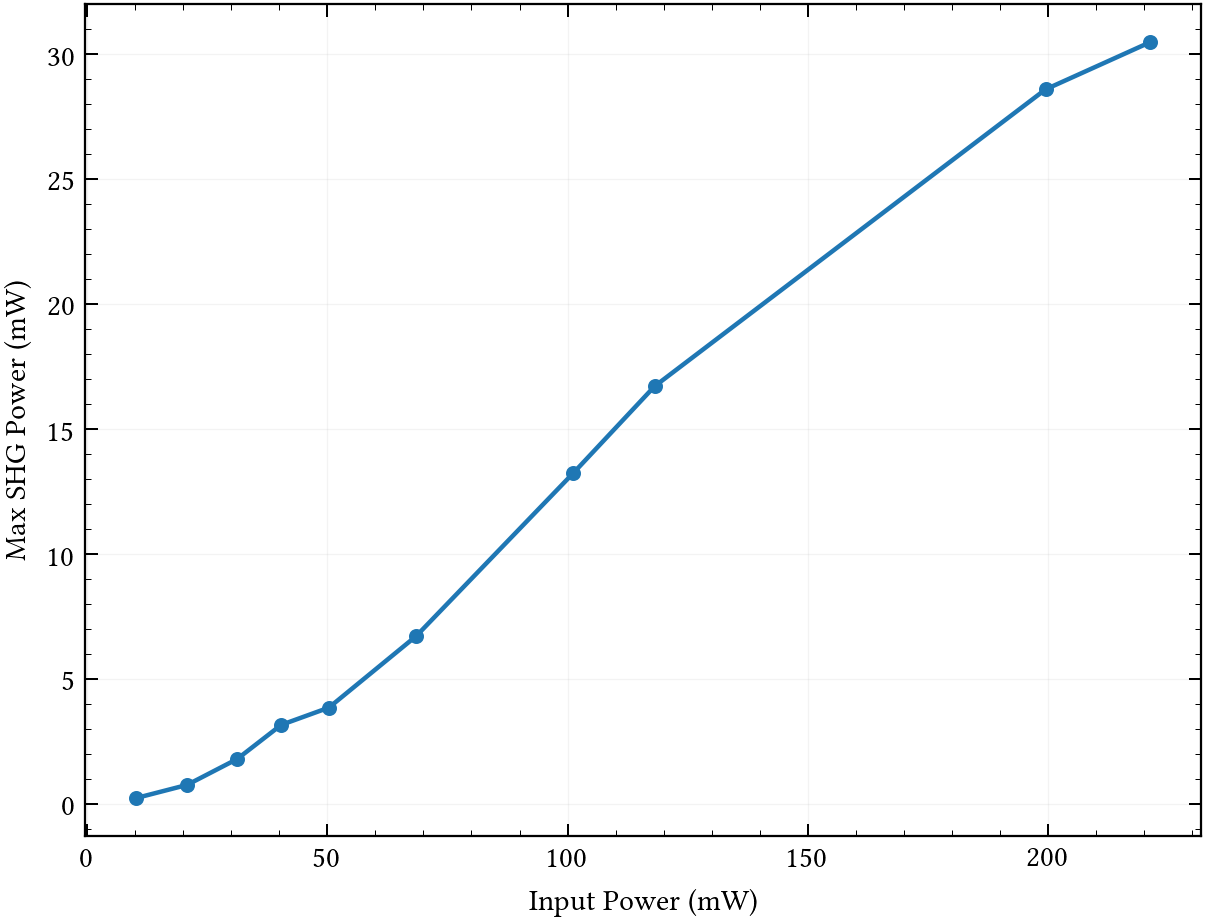

In [30]:
# Plot the max SHG power vs input power
plt.figure(figsize=(8, 6))
plt.plot(P_in, P_out_max, 'o-')
plt.xlabel('Input Power (mW)')
plt.ylabel('Max SHG Power (mW)')
# plt.title('Max SHG Power vs Input Power')
plt.grid()
plt.show()

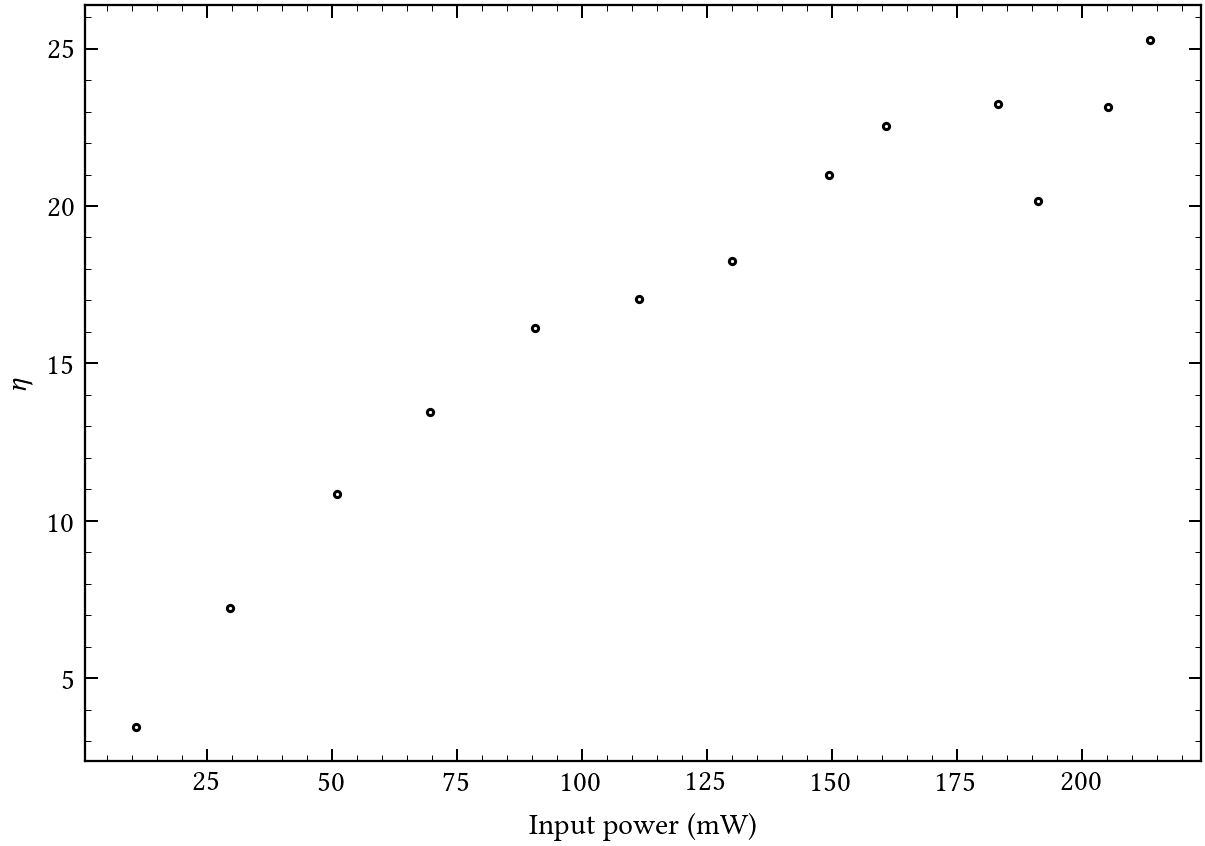

In [68]:
# Figure
fig, ax1 = plt.subplots(figsize=(7, 5))

eta = P_out_max / P_in * 100  # conversion to percentage

# -------------------------


# plt.plot(P_in, P_out, ".", color="black", markersize=5,
#          markerfacecolor="white", markeredgewidth=1.2, label="data points")
plt.plot(P_in, eta , ".", color="black", markersize=5,
         markerfacecolor="white", markeredgewidth=1.2, label="data points")
plt.xlabel("Input power (mW)")
# plt.ylabel("Output power (mW)")
plt.ylabel(r"$\eta$")
# plt.legend()
plt.tight_layout()
plt.show()

In [69]:
# SHG saturation model
def eta_model(P, eta_max, kappa):
    """
    P        : input power (mW)
    eta_max  : maximum conversion efficiency (fraction, not %)
    kappa    : nonlinear coupling parameter
    """
    return eta_max * np.tanh(np.sqrt(kappa * P))**2

In [77]:
# efficiency as a fraction
eta_frac = P_out_max / P_in

# remove any zero-power points
mask = np.isfinite(eta_frac) & (P_in > 0)

popt, pcov = curve_fit(
    eta_model,
    P_in[mask],
    eta_frac[mask],
    p0=[0.6, 0.01]
)

eta_max, kappa = popt

print(f"eta_max = {eta_max:.4f}")
print(f"kappa   = {kappa:.6f}")

# smooth curve for plotting
P_fit = np.linspace(0, P_in.max(), 500)

eta_fit = eta_model(P_fit, *popt)      # fraction
Pout_fit = P_fit * eta_fit             # mW
# Doubling efficiency (%)
eta = 100 * P_out_max / np.where(P_in == 0, np.nan, P_in)

eta_error = eta * np.sqrt(
    (P_out_error / P_out_max)**2 +
    (P_in_error / P_in)**2
)

eta_max = 0.3009
kappa   = 0.009323


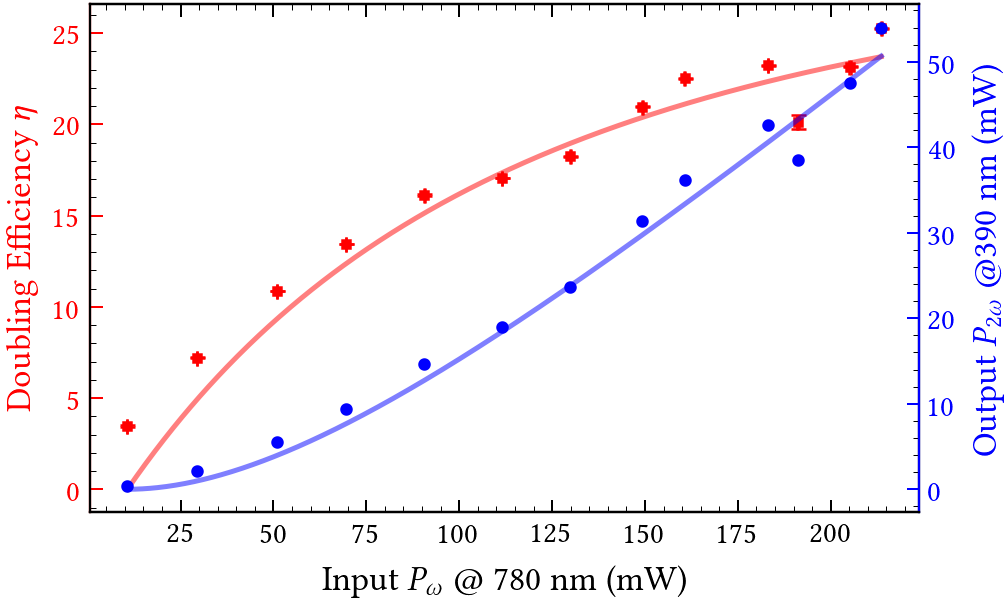

In [98]:
fig, ax1 = plt.subplots()

# -------------------------
# Left axis: efficiency
# -------------------------
# ax1.plot(
#     P_in, eta,
#     's', color='red',
#     markersize=5,
#     markerfacecolor='red',
#     label='Efficiency'
# )

ax1.errorbar(
    P_in,
    eta,
    xerr=P_in_error,
    yerr=eta_error,
    fmt='s',
    color='red',
    markersize=3,
    markerfacecolor='red',
    capsize=3,
    label='Efficiency'
)

ax1.plot(
    P_fit,
    100 * eta_fit,
    '-',
    color='red',
    alpha=0.5,
    lw=2
)

ax1.set_xlabel(r'Input $P_\omega$ @ 780 nm (mW)', fontsize=14)
ax1.set_ylabel(r'Doubling Efficiency $\eta$',
               color='red', fontsize=14)

ax1.tick_params(axis='y', colors='red')

# -------------------------
# Right axis: UV output power
# -------------------------
ax2 = ax1.twinx()

ax2.plot(
    P_in, P_out_max,
    '.',
    color='blue',
    markersize=5,
    markerfacecolor='white',
    markeredgewidth=2.5,
    label='UV power'
)

ax2.plot(
    P_fit,
    Pout_fit,
    '-',
    color='blue',
    alpha=0.5,
    lw=2
)

ax2.set_ylabel(r'Output $P_{2\omega}$ @390 nm (mW)',
               color='blue', fontsize=14)

ax2.tick_params(axis='y', colors='blue')


# Styling
ax1.spines['left'].set_color('red')
ax2.spines['right'].set_color('blue')

ax1.tick_params(labelsize=12)
ax2.tick_params(labelsize=12)

plt.tight_layout()
plt.show()

### Checking temperature drift

In [ ]:
def exp_decay(P, T_inf, A, P0):
    return T_inf + A * np.exp(-P / P0)

In [ ]:
p0 = [
    T_meas.min(),                    # T_inf
    T_meas.max() - T_meas.min(),     # A
    P_in.mean()                      # P0
]

popt, pcov = curve_fit(
    exp_decay,
    P_in,
    T_meas,
    sigma=T_meas_error,      # optional weighting
    absolute_sigma=True,
    p0=p0
)

T_inf, A, P0 = popt
dT_inf, dA, dP0 = np.sqrt(np.diag(pcov))

print(f"T_inf = {T_inf:.3f} ± {dT_inf:.3f}")
print(f"A     = {A:.3f} ± {dA:.3f}")
print(f"P0    = {P0:.3f} ± {dP0:.3f} mW")

T_inf = 42.318 ± 0.025
A     = 1.613 ± 0.022
P0    = 169.532 ± 4.971 mW


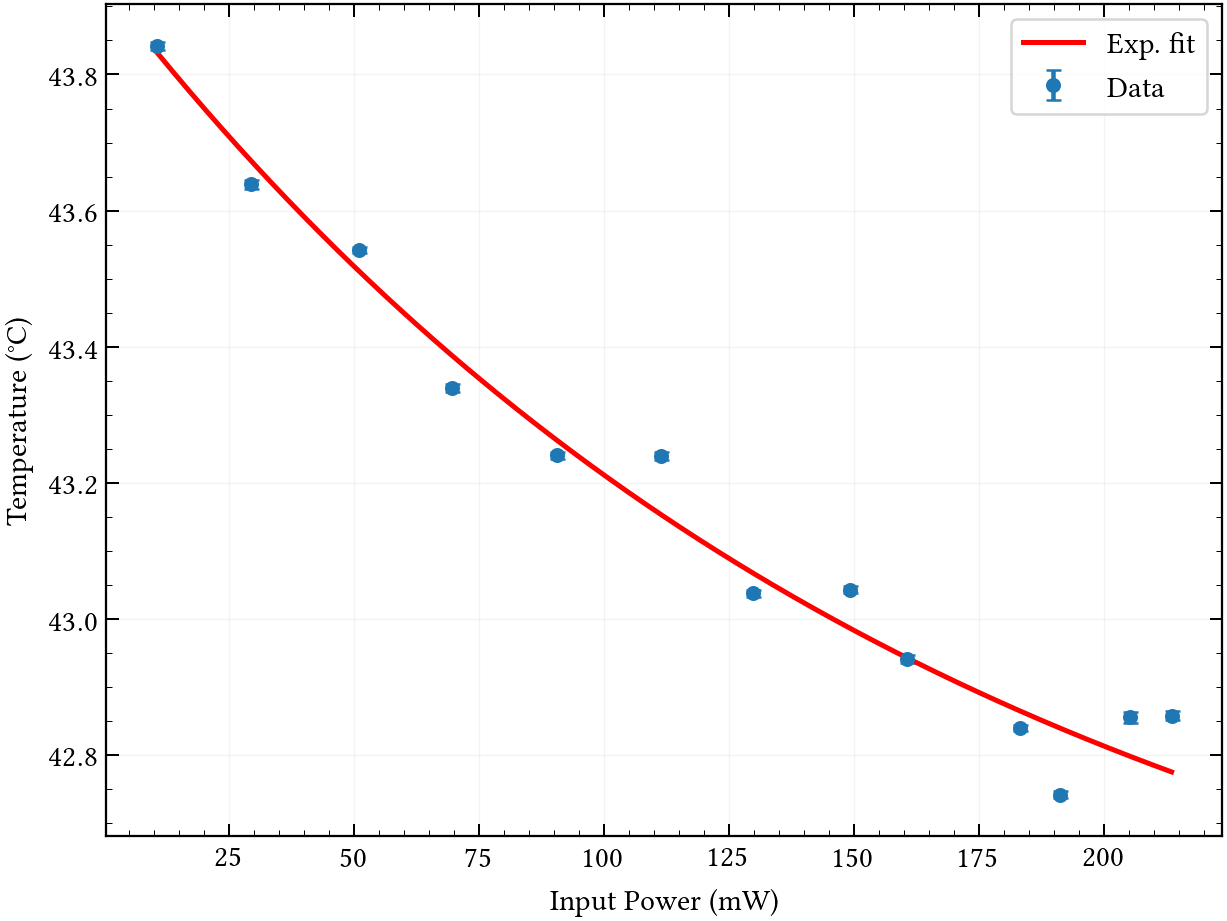

In [90]:
P_fit = np.linspace(P_in.min(), P_in.max(), 500)

plt.figure(figsize=(8,6))

plt.errorbar(
    P_in,
    T_meas,
    yerr=T_meas_error,
    fmt='o',
    capsize=3,
    label='Data'
)

plt.plot(
    P_fit,
    exp_decay(P_fit, *popt),
    'r-',
    lw=2,
    label='Exp. fit'
)

plt.xlabel('Input Power (mW)')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.show()

In [45]:
# Linear fit: T = a + b*P
coeffs_linear = np.polyfit(P_in, T_meas, 1)
T_fit_linear = np.polyval(coeffs_linear, P_in)

print(f"Linear coefficients: a = {coeffs_linear[1]:.3f}, b = {coeffs_linear[0]:.5f}")

Linear coefficients: a = 43.405, b = -0.00412


In [46]:
# Quadratic fit: T = a + b*P + c*P^2
coeffs_quad = np.polyfit(P_in, T_meas, 2)
T_fit_quad = np.polyval(coeffs_quad, P_in)

print(f"Quadratic coefficients: a = {coeffs_quad[2]:.3f}, b = {coeffs_quad[1]:.5f}, c = {coeffs_quad[0]:.7f}")

Quadratic coefficients: a = 43.376, b = -0.00323, c = -0.0000038


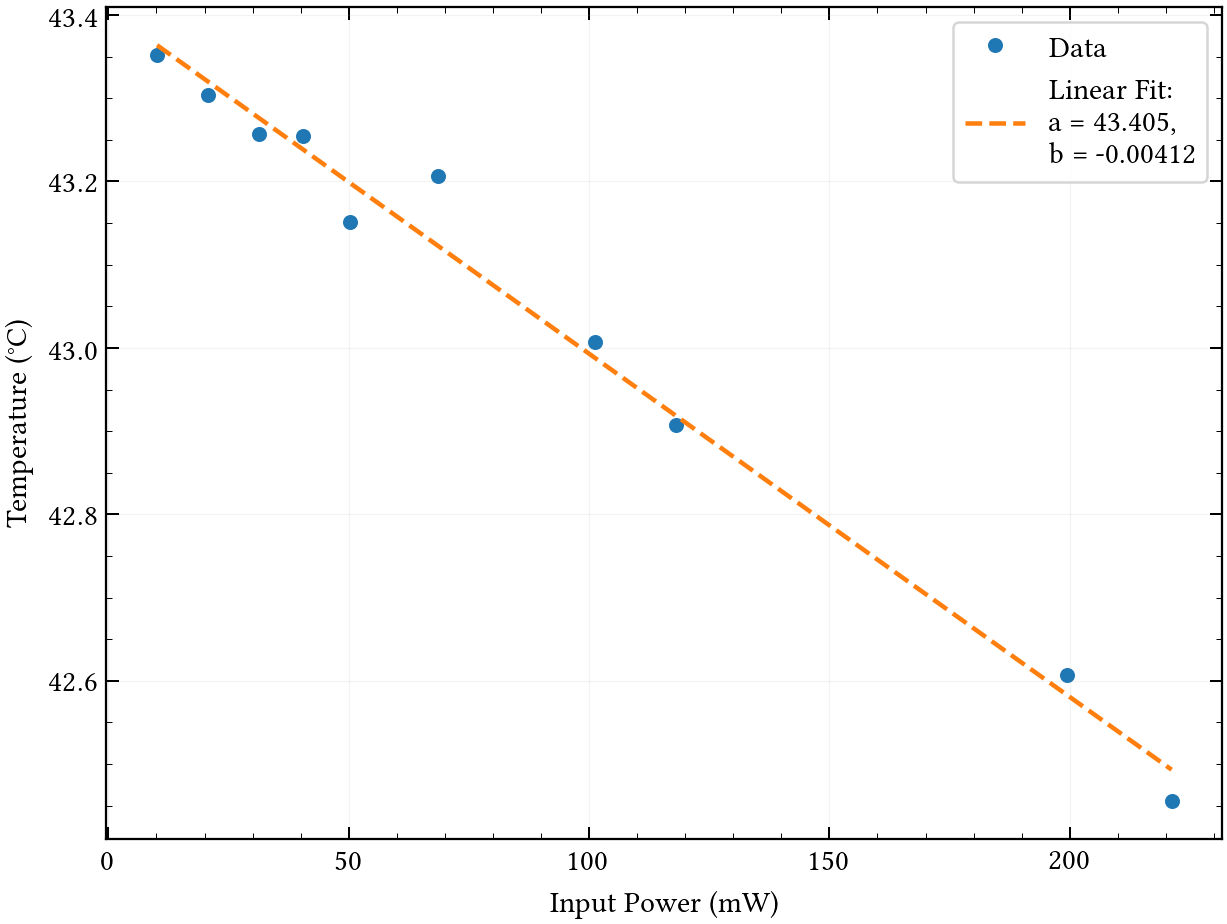

In [48]:
plt.figure(figsize=(8, 6))
plt.plot(P_in, T_meas, 'o', label='Data')
plt.plot(P_in, T_fit_linear, '--', label=f'Linear Fit:\na = {coeffs_linear[1]:.3f},\nb = {coeffs_linear[0]:.5f}')
# plt.plot(P_in, T_fit_quad, '-', label='Quadratic Fit')
# plt.plot(P_in, T_fit_exp, '-.', label='Exponential Fit')
plt.xlabel('Input Power (mW)')
plt.ylabel('Temperature (°C)')
plt.grid()
plt.legend()
plt.show()

In [44]:
# Extrapolate each fit to P = 0
P_zero = 0
T_linear_zero = np.polyval(coeffs_linear, P_zero)
T_quad_zero = np.polyval(coeffs_quad, P_zero)

print(f"Extrapolated T at P=0 mW:")
print(f"Linear: {T_linear_zero:.3f} °C")
print(f"Quadratic: {T_quad_zero:.3f} °C")

Extrapolated T at P=0 mW:
Linear: 43.405 °C
Quadratic: 43.376 °C


## Waist scan

In [12]:
# Manually define the waist corresponding to each focal length
# Forgot to add it before in the acquisition notebook, so I add it here for the plot
# Won't be necessary for the future, it is added in the acquisition notebook
waists = {
    500.0: 70.1,  # mm & µm
    400.0: 53.5,  # mm & µm
    200.0: 24.5   # mm & µm
}

In [13]:
path_folder_data = r"./data/data_temp_SHG/waist_scan 05 05"
folder_data_files = os.listdir(path_folder_data)
print(folder_data_files)

['temp.json', 'waist_scan']


In [14]:
# List all files in the folder
name_exp = 'waist_scan'
folder_data_files = os.listdir(path_folder_data + '/' + name_exp)
print(folder_data_files)

['2026_05_05__15_08_16__waist_scan.h5', '2026_05_05__15_10_23__waist_scan.h5', '2026_05_05__15_15_47__waist_scan.h5']


In [15]:

w_list = []
eta_list = []
eta_err_list = []

aqm = AcquisitionAnalysisManager( os.path.join(path_folder_data, name_exp))

for name in folder_data_files:
    full_path = os.path.join(path_folder_data, name_exp, name)
    aqm.analysis_cell(filename=full_path)

    Pin = float(aqm.data["Pin"])        # mW
    Pshg = float(aqm.data["mean_mW"])   # mW
    Perr = float(aqm.data["error_mW"])  # mW

    eta = Pshg / Pin # conversion efficiency
    eta_err = Perr / Pin

    f = float(aqm.data["focal_length_mm"])
    waist = waists.get(f, None)

    w_list.append(waist)
    eta_list.append(eta)
    eta_err_list.append(eta_err)

    # print(aqm.data)

INFO:2026_05_05__15_08_16__waist_scan


INFO:2026_05_05__15_10_23__waist_scan


INFO:2026_05_05__15_15_47__waist_scan


In [16]:
# Convert to arrays
w = np.array(w_list)
eta = np.array(eta_list)
eta_err = np.array(eta_err_list)

print("Waists (µm):", w)
print("Conversion efficiencies:", eta)

Waists (µm): [53.5 24.5 70.1]
Conversion efficiencies: [0.0006781  0.00140509 0.00060392]


In [17]:
# Fit the data to the model eta(w0) = A * w0^2 / (w0^4 + wc^4)
def eta_model(w0, A, wc):
    """
    For larger waists, the conversion efficiency decreases as 1/w0^2, while for smaller waists, it decreases as w0^2. The maximum efficiency occurs at w0 = wc, where eta(wc) = A/2.
    :param w0: beam waist (µm)
    :param A: maximum conversion efficiency (at w0 = wc)
    :param wc: optimal beam waist for maximum conversion efficiency (µm)

    :return: conversion efficiency eta
    """
    return A * w0**2 / (w0**4 + wc**4)

# Initial guess for fitting parameters
p0 = [np.max(eta), np.mean(w)]
popt, pcov = curve_fit(eta_model, w, eta, p0=p0, sigma=eta_err, absolute_sigma=True)
w_fit = np.linspace(10, 80, 200)
eta_fit_values = eta_model(w_fit, *popt)

In [18]:
L = 20e-3  # 20 mm in meters

# Boyd-Kleinman focusing function for perfect phase matching
def bk_h(xi):
    """
    Minimal Boyd-Kleinman focusing function for perfect phase matching.
    :param xi: xi = L / (2 z_R)
    """

    def integrand(t):
        return 1 / (1 + 1j*t)

    val, _ = quad(lambda t: np.real(integrand(t)), -xi, xi)
    vali, _ = quad(lambda t: np.imag(integrand(t)), -xi, xi)

    I = val + 1j * vali

    return np.abs(I)**2 / (4 * xi)


def eta_bk(w0_um, A, s):
    """
    Boyd-Kleinman model for SHG efficiency.
    :param w0_um: measured waist in um
    :param A: global efficiency scale
    :param s: waist calibration factor

    :return: conversion efficiency eta 
    """

    w0 = s * w0_um * 1e-6
    zR = np.pi * w0**2 / wavelength
    xi = L / (2 * zR)

    h = np.array([bk_h(x) for x in xi])

    return A * h

p0 = [np.max(eta), 1.0]

popt, pcov = curve_fit(
    eta_bk,
    w,
    eta,
    p0=p0,
    sigma=eta_err,
    absolute_sigma=True,
    bounds=([0, 0.3], [np.inf, 3.0]),
    maxfev=10000
)

A_fit, s_fit = popt

print(f"A = {A_fit:.4e}")
print(f"waist calibration factor s = {s_fit:.3f}")

w_fit = np.linspace(10, 90, 200)
eta_fit_values_bk = eta_bk(w_fit, *popt)

A = 2.2246e-03
waist calibration factor s = 1.517


Optimal waist from simple model: 30.9 µm
Optimal waist from Boyd-Kleinman model: 27.7 µm


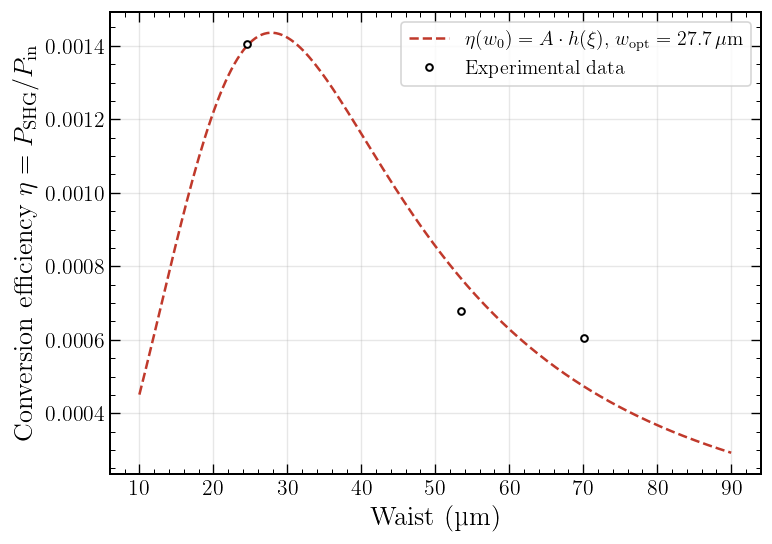

In [27]:
# Plot the coefficient eta vs waist
plt.figure(figsize=(7,5))

# Curve fits
w0_optimal = w_fit[np.argmax(eta_fit_values)]
w0_optimal_bk = w_fit[np.argmax(eta_fit_values_bk)]
print(f"Optimal waist from simple model: {w0_optimal:.1f} µm")
print(f"Optimal waist from Boyd-Kleinman model: {w0_optimal_bk:.1f} µm")
# plt.plot(w_fit[w0_optimal], eta_fit_values[w0_optimal], 'rx', label=f'$w_{{opt}}=${w_fit[w0_optimal]:.1f} µm')
# plt.plot(w_fit[w0_optimal_bk], eta_fit_values_bk[w0_optimal_bk], 'gx', label=f'$w_{{opt}}=${w_fit[w0_optimal_bk]:.1f} µm')
# plt.plot(
#     w_fit,
#     eta_fit_values,
#     'r--',
#     label=rf'$\eta(w_0)=\frac{{A w_0^2}}{{w_0^4+w_c^4}}$, '
#           rf'$w_{{\mathrm{{opt}}}}={w0_optimal:.1f}\,\mu\mathrm{{m}}$'
# )

plt.plot(
    w_fit,
    eta_fit_values_bk,
    color="#C0392B",
    linestyle="--",
    linewidth=1.5,
    label=rf'$\eta(w_0) = A \cdot h(\xi)$, '
          rf'$w_{{\mathrm{{opt}}}}={w0_optimal_bk:.1f}\,\mu\mathrm{{m}}$'
)

# plt.errorbar(
#     w, 
#     eta, 
#     yerr=eta_err, 
#     fmt='o', 
#     color="black",
#     markersize=4,
#     markerfacecolor="white",
#     markeredgewidth=1.2,
#     capsize=3, 
#     label='Experimental data'
# )

plt.plot(
    w, 
    eta, 
    'o',
    color="black",
    markersize=4,
    markerfacecolor="white",
    markeredgewidth=1.2,
    label='Experimental data'
)

plt.xlabel("Waist (µm)")
plt.ylabel(r"Conversion efficiency $\eta = P_{\mathrm{SHG}} / P_{\mathrm{in}}$")
# plt.title("SHG efficiency vs waist")
plt.legend(loc='upper right')

plt.grid(alpha=0.3)
# plt.tight_layout()
plt.show()

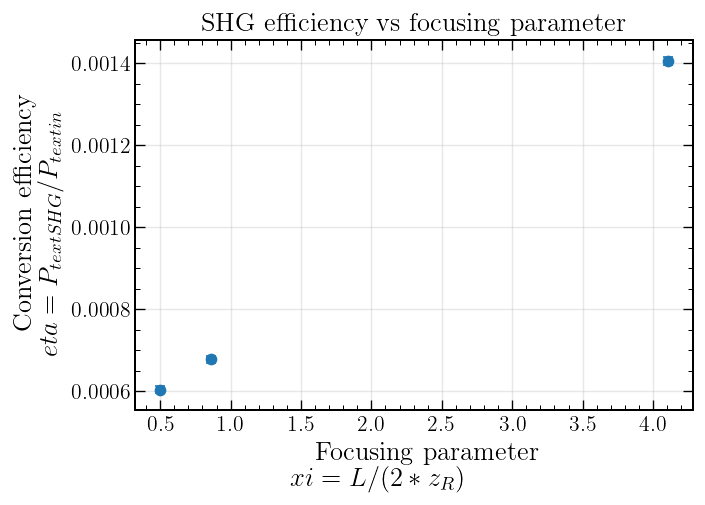

In [23]:
# Plot efficiency eta vs focusing parameter xi = L / (2 * z_R)
L = 20.0  # mm
z_R = np.pi * w**2 / (780-6)  # Rayleigh range in mm
xi = L / (2 * z_R)
plt.figure()
plt.errorbar(xi, eta, yerr=eta_err, fmt='o', capsize=3)
plt.xlabel(r"Focusing parameter $\\xi = L / (2 * z_R)$")
plt.ylabel(r"Conversion efficiency $\\eta = P_{\\text{SHG}} / P_{\\text{in}}$")
plt.title("SHG efficiency vs focusing parameter")
plt.grid()
plt.show()